In [1]:
import pandas as pd
import os
import json
import sqlite3

movies_path = None
credits_path = None

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file == "tmdb_5000_movies.csv":
            movies_path = os.path.join(root, file)
        if file == "tmdb_5000_credits.csv":
            credits_path = os.path.join(root, file)

print("Movies path:", movies_path)
print("Credits path:", credits_path)

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

json_columns_movies = [
    'genres',
    'keywords',
    'production_companies',
    'production_countries',
    'spoken_languages'
]

for col in json_columns_movies:
    movies[col] = movies[col].apply(json.loads)

credits['cast'] = credits['cast'].apply(json.loads)
credits['crew'] = credits['crew'].apply(json.loads)

movie_df = movies[['id', 'title', 'popularity', 'release_date', 'vote_average']].copy()
movie_df = movie_df.rename(columns={'id': 'movie_id'})

genre_rows = []
movie_genre_rows = []

for _, row in movies.iterrows():
    movie_id = row['id']
    for genre in row['genres']:
        genre_rows.append({
            'genre_id': genre['id'],
            'name': genre['name']
        })
        movie_genre_rows.append({
            'movie_id': movie_id,
            'genre_id': genre['id']
        })

genre_df = pd.DataFrame(genre_rows).drop_duplicates()
movie_genre_df = pd.DataFrame(movie_genre_rows).drop_duplicates()

keyword_rows = []
movie_keyword_rows = []

for _, row in movies.iterrows():
    movie_id = row['id']
    for keyword in row['keywords']:
        keyword_rows.append({
            'keyword_id': keyword['id'],
            'name': keyword['name']
        })
        movie_keyword_rows.append({
            'movie_id': movie_id,
            'keyword_id': keyword['id']
        })

keyword_df = pd.DataFrame(keyword_rows).drop_duplicates()
movie_keyword_df = pd.DataFrame(movie_keyword_rows).drop_duplicates()

company_rows = []
movie_company_rows = []

for _, row in movies.iterrows():
    movie_id = row['id']
    for company in row['production_companies']:
        company_rows.append({
            'company_id': company['id'],
            'name': company['name']
        })
        movie_company_rows.append({
            'movie_id': movie_id,
            'company_id': company['id']
        })

company_df = pd.DataFrame(company_rows).drop_duplicates()
movie_company_df = pd.DataFrame(movie_company_rows).drop_duplicates()

language_rows = []
movie_language_rows = []

for _, row in movies.iterrows():
    movie_id = row['id']
    for language in row['spoken_languages']:
        language_rows.append({
            'language_code': language['iso_639_1'],
            'name': language['name']
        })
        movie_language_rows.append({
            'movie_id': movie_id,
            'language_code': language['iso_639_1']
        })

language_df = pd.DataFrame(language_rows).drop_duplicates()
movie_language_df = pd.DataFrame(movie_language_rows).drop_duplicates()

actor_rows = []
movie_cast_rows = []

for _, row in credits.iterrows():
    movie_id = row['movie_id']
    for actor in row['cast']:
        actor_rows.append({
            'actor_id': actor['id'],
            'name': actor['name']
        })
        movie_cast_rows.append({
            'movie_id': movie_id,
            'actor_id': actor['id']
        })

actor_df = pd.DataFrame(actor_rows).drop_duplicates()
movie_cast_df = pd.DataFrame(movie_cast_rows).drop_duplicates()

conn = sqlite3.connect('/kaggle/working/tmdb_movies_normalized.db')
cursor = conn.cursor()

cursor.execute("PRAGMA foreign_keys = ON;")

cursor.executescript("""
DROP TABLE IF EXISTS Movie_Production_Company;
DROP TABLE IF EXISTS Movie_Language;
DROP TABLE IF EXISTS Movie_Cast;
DROP TABLE IF EXISTS Movie_Keyword;
DROP TABLE IF EXISTS Movie_Genre;
DROP TABLE IF EXISTS Production_Company;
DROP TABLE IF EXISTS Language;
DROP TABLE IF EXISTS Actor;
DROP TABLE IF EXISTS Keyword;
DROP TABLE IF EXISTS Genre;
DROP TABLE IF EXISTS Movie;

CREATE TABLE Movie (
    movie_id INTEGER PRIMARY KEY,
    title TEXT,
    popularity REAL,
    release_date TEXT,
    vote_average REAL
);

CREATE TABLE Genre (
    genre_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE Keyword (
    keyword_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE Actor (
    actor_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE Language (
    language_code TEXT PRIMARY KEY,
    name TEXT
);

CREATE TABLE Production_Company (
    company_id INTEGER PRIMARY KEY,
    name TEXT
);

CREATE TABLE Movie_Genre (
    movie_id INTEGER,
    genre_id INTEGER,
    PRIMARY KEY (movie_id, genre_id),
    FOREIGN KEY (movie_id) REFERENCES Movie(movie_id),
    FOREIGN KEY (genre_id) REFERENCES Genre(genre_id)
);

CREATE TABLE Movie_Keyword (
    movie_id INTEGER,
    keyword_id INTEGER,
    PRIMARY KEY (movie_id, keyword_id),
    FOREIGN KEY (movie_id) REFERENCES Movie(movie_id),
    FOREIGN KEY (keyword_id) REFERENCES Keyword(keyword_id)
);

CREATE TABLE Movie_Cast (
    movie_id INTEGER,
    actor_id INTEGER,
    PRIMARY KEY (movie_id, actor_id),
    FOREIGN KEY (movie_id) REFERENCES Movie(movie_id),
    FOREIGN KEY (actor_id) REFERENCES Actor(actor_id)
);

CREATE TABLE Movie_Language (
    movie_id INTEGER,
    language_code TEXT,
    PRIMARY KEY (movie_id, language_code),
    FOREIGN KEY (movie_id) REFERENCES Movie(movie_id),
    FOREIGN KEY (language_code) REFERENCES Language(language_code)
);

CREATE TABLE Movie_Production_Company (
    movie_id INTEGER,
    company_id INTEGER,
    PRIMARY KEY (movie_id, company_id),
    FOREIGN KEY (movie_id) REFERENCES Movie(movie_id),
    FOREIGN KEY (company_id) REFERENCES Production_Company(company_id)
);
""")

movie_df.to_sql('Movie', conn, if_exists='append', index=False)
genre_df.to_sql('Genre', conn, if_exists='append', index=False)
keyword_df.to_sql('Keyword', conn, if_exists='append', index=False)
actor_df.to_sql('Actor', conn, if_exists='append', index=False)
language_df.to_sql('Language', conn, if_exists='append', index=False)
company_df.to_sql('Production_Company', conn, if_exists='append', index=False)

movie_genre_df.to_sql('Movie_Genre', conn, if_exists='append', index=False)
movie_keyword_df.to_sql('Movie_Keyword', conn, if_exists='append', index=False)
movie_cast_df.to_sql('Movie_Cast', conn, if_exists='append', index=False)
movie_language_df.to_sql('Movie_Language', conn, if_exists='append', index=False)
movie_company_df.to_sql('Movie_Production_Company', conn, if_exists='append', index=False)

conn.commit()

tables = pd.read_sql("""
SELECT name 
FROM sqlite_master 
WHERE type='table';
""", conn)

print("Base de datos creada correctamente.")
print("Archivo creado en: /kaggle/working/tmdb_movies_normalized.db")
print(tables)

Movies path: /kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
Credits path: /kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv
Base de datos creada correctamente.
Archivo creado en: /kaggle/working/tmdb_movies_normalized.db
                        name
0                      Movie
1                      Genre
2                    Keyword
3                      Actor
4                   Language
5         Production_Company
6                Movie_Genre
7              Movie_Keyword
8                 Movie_Cast
9             Movie_Language
10  Movie_Production_Company


## ETL (Extraer, Transformar, Cargar)

Este proceso corresponde a la fase de transformación dentro del ETL.

En esta fase, trabajamos con archivos CSV que contienen información sobre películas.

Primero, cargamos los datos con la ayuda de la librería Pandas.

Luego, encontramos varias columnas que tienen datos en formato JSON, como géneros, palabras clave, compañías de producción, idiomas hablados, elenco y equipo.

La verdad es que estos datos no están en un formato adecuado para bases de datos relacionales, ya que tienen listas dentro de una misma columna.

Por eso, usamos la función json.loads() para convertir estos valores de texto a listas y diccionarios en Python.

Este paso es fundamental porque nos permite preparar los datos para normalizarlos en varias tablas más adelante.

## Diagrama Entidad-Relación

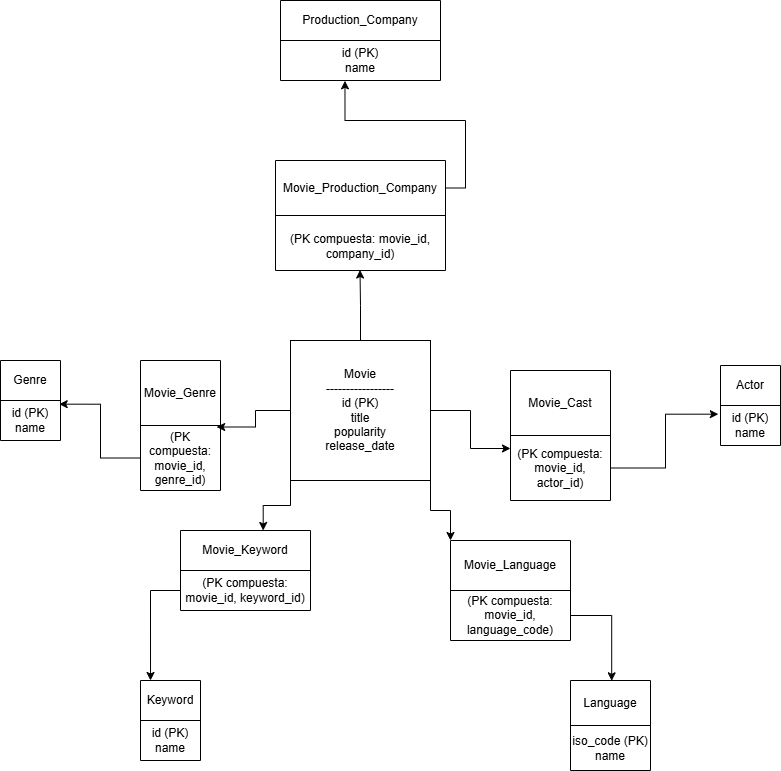

## Normalización de la Base de Datos

En esta fase, aplicamos un proceso para transformar los datos en un modelo eficiente y sin información repetida.

### Primera Forma Normal (1NF)

Eliminamos los atributos que tenían varios valores, como géneros, palabras clave, elenco y idiomas hablados. Estos valores estaban almacenados como listas en formato JSON en una sola columna.

Para cumplir con 1NF, separamos estos valores en tablas independientes. Así, cada campo contiene solo valores simples.

### Segunda Forma Normal (2NF)

Eliminamos las dependencias parciales creando tablas maestras como Género, Actor, Palabra Clave, Idioma y Compañía de Producción.

De esta manera, cada atributo depende completamente de su clave principal. Esto evita que se duplique información en la tabla principal de Películas.

### Tercera Forma Normal (3NF)

Eliminamos las dependencias transitivas. Esto asegura que los atributos no dependan de otros atributos que no sean la clave principal.

Por ejemplo, los nombres de géneros, actores e idiomas se almacenan en sus propias tablas. No se almacenan directamente en la tabla de Películas.

### Forma Normal de Boyce-Codd (BCNF) / Cuarta Forma Normal (4NF)

Resolvimos dependencias multivaluadas. Separamos relaciones independientes en tablas intermedias.

Una película puede tener varios actores, géneros, idiomas y palabras clave. Pero estas relaciones son independientes entre sí.

Para manejar esto, creamos tablas intermedias como:

- Película_Género

- Película_Elenco

- Película_Palabra Clave

- Película_Idioma

- Película_Compañía de Producción

Esto garantiza que la base de datos esté completamente normalizada y sin información repetida.

## Implementación de la Base de Datos SQLite

En esta fase, creamos una base de datos SQLite que se llama `tmdb_movies_normalized.db`.

Con los datos que ya habíamos procesado, creamos tablas en la base de datos. Estas tablas siguen el diseño que se ve en el diagrama de entidad-relación.

Las tablas principales son Movie, Genre, Actor, Keyword, Language y Production_Company. También creamos tablas intermedias para mostrar las relaciones entre las películas y sus géneros, actores, palabras clave, lenguajes y compañías productoras.

Finalmente, cargamos los DataFrames normalizados en la base de datos SQLite.